##Cel projektu
Celem niniejszego projektu jest zbadanie korelacji pomiędzy różnymi parametrami demograficznymi, społecznymi i szkolnymi a końcowymi wynikami uczniów w nauce. Projekt skupia się na wykorzystaniu modelu regresji, aby sprawdzić, które czynniki (np. czas nauki, nieobecności, wcześniejsze niepowodzenia) mają największy wpływ na sukces edukacyjny.

##Zbiór danych
Zbiór danych pochodzi z bazy UCI Machine Learning Repository i dotyczy wyników uczniów dwóch portugalskich szkół średnich.

Liczba obserwacji: 395 uczniów.

Liczba cech: 33 (w tym dane demograficzne, rodzinne i szkolne).

##Zakres analizy
W projekcie skupiono się na danych numerycznych, aby zbadać bezpośrednie zależności matematyczne i zbudować model regresyjny przewidujący ocenę końcową na podstawie mierzalnych parametrów stylu życia i historii edukacyjnej ucznia.

In [59]:
import os
if not os.path.exists('student-mat.csv'):
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip
    !unzip student.zip student-mat.csv

In [60]:
import pandas as pd

df = pd.read_csv('student-mat.csv', sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [62]:
print(df.dtypes.value_counts())

object    17
int64     16
Name: count, dtype: int64


W ramach przygotowania danych do analizy usunięto kolumny, które nie wnoszą istotnych informacji do modelu. Pozwoliło to na ograniczenie liczby cech i uproszczenie struktury danych bez utraty kluczowych zależności.

In [63]:
cols_to_drop = ['school', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'schoolsup', 'famsup', 'nursery']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

print(df.columns.tolist())
print(f"Liczba kolumn po czyszczeniu: {len(df_cleaned.columns)}")
df = df_cleaned

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Liczba kolumn po czyszczeniu: 21


In [64]:
# Sprawdzenie ile jest kolumn tekstowych w tych 21 kolumnach
text_columns = df.select_dtypes(include=['object']).columns.tolist()

print(f"Liczba kolumn do zmiany (tekstowych): {len(text_columns)}")
print("Oto one:", text_columns)

Liczba kolumn do zmiany (tekstowych): 6
Oto one: ['sex', 'paid', 'activities', 'higher', 'internet', 'romantic']


Przed przystąpieniem do dalszej analizy sprawdzono kompletność zbioru danych.
Zweryfikowano czy w zbiorze występują brakujące wartości oraz zduplikowane wiersze,
które mogłyby negatywnie wpłynąć na jakość modelu.

In [65]:
print("Braki danych")
print(df.isnull().sum())
print(f"\nŁączna liczba braków: {df.isnull().sum().sum()}")
print(f"\nLiczba duplikatów: {df.duplicated().sum()}")

Braki danych
sex           0
age           0
Medu          0
Fedu          0
studytime     0
failures      0
paid          0
activities    0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Łączna liczba braków: 0

Liczba duplikatów: 0


In [66]:
# Zamiana tekstu na 0 i 1
mapping = {
'yes': 1, 'no': 0,
'F': 1, 'M': 0,
}

# Lista kolumn
cols_to_map = ['sex', 'paid', 'activities', 'higher', 'internet', 'romantic']

# Pętla zamieniająca wartości w każdej z tych kolumn
for col in cols_to_map:
    if col in df.columns:
        df[col] = df[col].map(mapping)
# Sprawdzenie, czy udało się poprawnie zamienić
print(df[cols_to_map].head())


   sex  paid  activities  higher  internet  romantic
0    1     0           0       1         0         0
1    1     0           0       1         1         0
2    1     1           0       1         1         0
3    1     1           1       1         1         1
4    1     1           0       1         0         0


# Przygotowanie danych: Konwersja skali ocen
W oryginalnym zbiorze danych oceny uczniów (G1, G2, G3) prezentowane są w skali punktowej od 0 do 20, co jest standardem w systemie edukacji w Portugalii. Aby analiza była bardziej intuicyjna oraz aby umożliwić jednoznaczną interpretację wyników, zdecydowano o przeprowadzeniu transformacji ocen na polski system oceniania (skala 1-6).

Schemat konwersji:

18 - 20 pkt → 6 (Celujący)

16 - 17 pkt → 5 (Bardzo dobry)

14 - 15 pkt → 4 (Dobry)

12 - 13 pkt → 3 (Dostateczny)

10 - 11 pkt → 2 (Dopuszczający)

0 - 9 pkt → 1 (Niedostateczny)

In [67]:
def przelicz_ocene(punkty):
    if 18 <= punkty <= 20:
        return 6  # Celujący
    elif 16 <= punkty <= 17:
        return 5  # Bardzo dobry
    elif 14 <= punkty <= 15:
        return 4  # Dobry
    elif 12 <= punkty <= 13:
        return 3  # Dostateczny
    elif 10 <= punkty <= 11:
        return 2  # Dopuszczający
    else:
        return 1  # Niedostateczny

# Zastosowanie funkcji do ocen G1, G2 i G3
oceny_cols = ['G1', 'G2', 'G3']
for col in oceny_cols:
    df[col] = df[col].apply(przelicz_ocene)

print(df[['G1', 'G2', 'G3']].head())

   G1  G2  G3
0   1   1   1
1   1   1   1
2   1   1   2
3   4   4   4
4   1   2   2


array([[<Axes: title={'center': 'sex'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'Medu'}>,
        <Axes: title={'center': 'Fedu'}>,
        <Axes: title={'center': 'studytime'}>],
       [<Axes: title={'center': 'failures'}>,
        <Axes: title={'center': 'paid'}>,
        <Axes: title={'center': 'activities'}>,
        <Axes: title={'center': 'higher'}>,
        <Axes: title={'center': 'internet'}>],
       [<Axes: title={'center': 'romantic'}>,
        <Axes: title={'center': 'famrel'}>,
        <Axes: title={'center': 'freetime'}>,
        <Axes: title={'center': 'goout'}>,
        <Axes: title={'center': 'Dalc'}>],
       [<Axes: title={'center': 'Walc'}>,
        <Axes: title={'center': 'health'}>,
        <Axes: title={'center': 'absences'}>,
        <Axes: title={'center': 'G1'}>, <Axes: title={'center': 'G2'}>],
       [<Axes: title={'center': 'G3'}>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

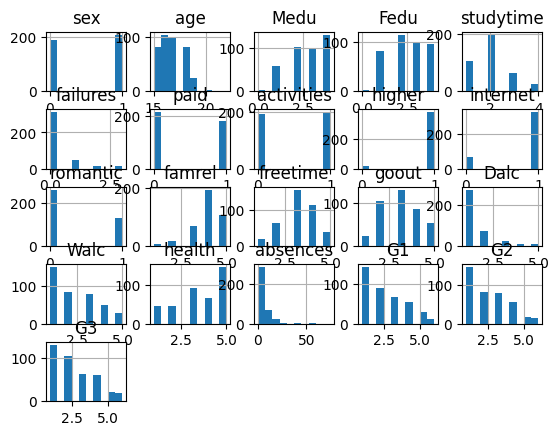

In [68]:
df.hist()

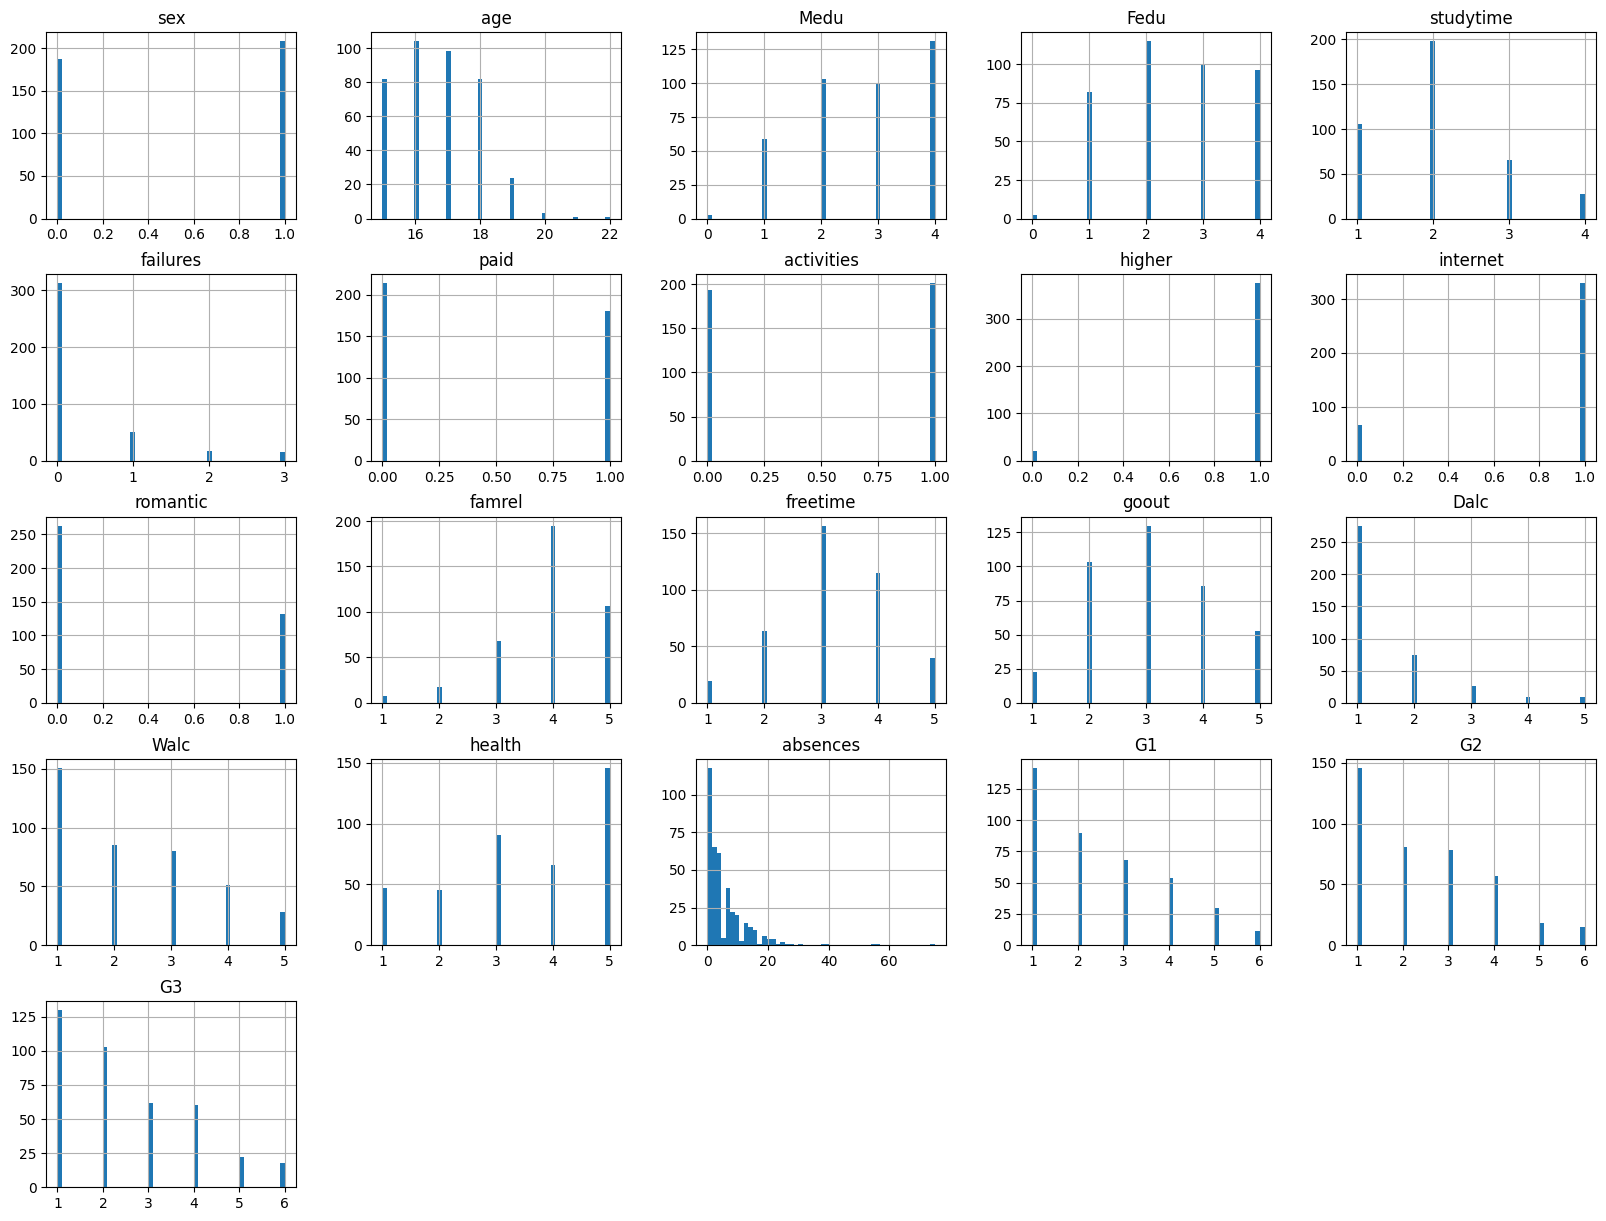

In [69]:
%matplotlib inline
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20, 15))
plt.show()

# Podział danych na zbiór treningowy i testowy

Zastosowano metodę StratifiedShuffleSplit, która gwarantuje, że rozkład ocen (G3) w zbiorze treningowym i testowym będzie taki sam, jak w całym zbiorze wyjściowym.

Jest to kluczowe, aby model "widział" uczniów o wszystkich wynikach (od najsłabszych do najlepszych) w obu zestawach danych, co znacząco poprawia jakość uczenia modelu.

In [70]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Podział wykonujemy według oceny G3, żeby w obu zbiorach rozkład ocen był reprezentatywny dla całego zbioru
for train_index, test_index in split.split(df, df["G3"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# Tworzymy ostateczne X i y dla modelu
X_train = strat_train_set.drop("G3", axis=1)
y_train = strat_train_set["G3"].copy()

X_test = strat_test_set.drop("G3", axis=1)
y_test = strat_test_set["G3"].copy()

print(f"Liczba danych w zbiorze treningowym: {len(strat_train_set)}")
print(f"Liczba danych w zbiorze testowym: {len(strat_test_set)}")

Liczba danych w zbiorze treningowym: 316
Liczba danych w zbiorze testowym: 79


In [71]:
# Sprawdzenie rozkładu ocen w całym zbiorze
print("Rozkład w całym zbiorze:")
print(df["G3"].value_counts() / len(df))

# Sprawdzenie rozkładu ocen w zbiorze treningowym (strat_train_set)
print("\nRozkład w zbiorze treningowym:")
print(strat_train_set["G3"].value_counts() / len(strat_train_set))

Rozkład w całym zbiorze:
G3
1    0.329114
2    0.260759
3    0.156962
4    0.151899
5    0.055696
6    0.045570
Name: count, dtype: float64

Rozkład w zbiorze treningowym:
G3
1    0.329114
2    0.259494
3    0.158228
4    0.151899
5    0.056962
6    0.044304
Name: count, dtype: float64


In [72]:
# Tworzymy kopię zbioru treningowego do celów eksploracji i wizualizacji
df_train = strat_train_set.copy()

# Wizualizacja rozkładu danych oraz badanie korelacji.

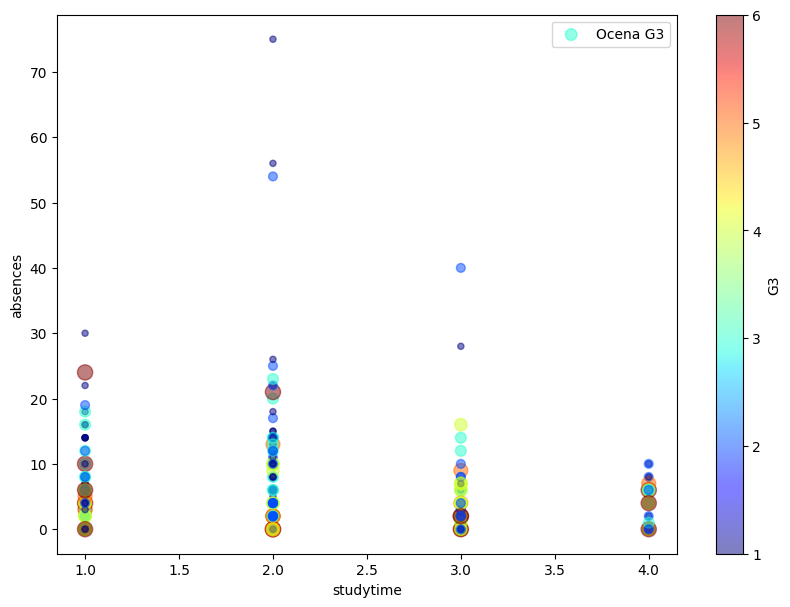

In [73]:
# Wizualizacja wpływu czasu nauki i nieobecności na ocenę końcową
df_train.plot(kind="scatter", x="studytime", y="absences", alpha=0.5,
    s=df_train["G3"]*20, label="Ocena G3",
    c="G3", cmap=plt.get_cmap("jet"), colorbar=True,
    figsize=(10,7)
)
plt.legend()
plt.show()

In [74]:
# Analiza korelacji wybranych zmiennych z oceną końcową
attributes = ["G3", "G1", "G2", "studytime", "absences"]
corr_matrix = df_train[attributes].corr()
print(corr_matrix["G3"].sort_values(ascending=False))


G3           1.000000
G2           0.946883
G1           0.871069
studytime    0.091607
absences    -0.126557
Name: G3, dtype: float64


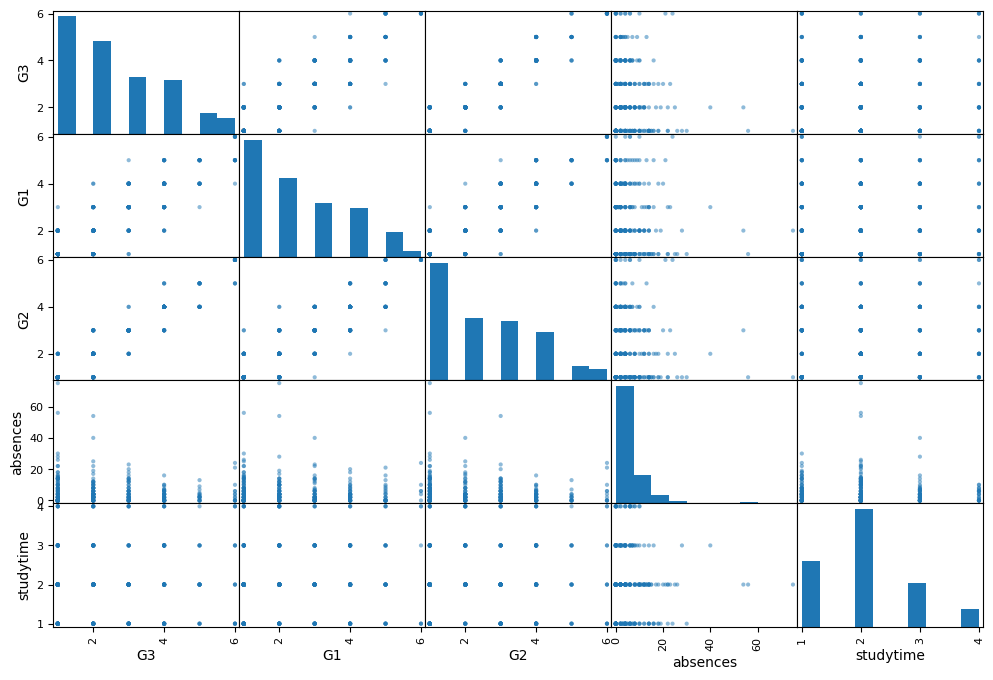

In [75]:
# Wizualizacja wzajemnych zależności (Scatter Matrix)
from pandas.plotting import scatter_matrix
attributes = ["G3", "G1", "G2", "absences", "studytime"]
scatter_matrix(df_train[attributes], figsize=(12, 8))
plt.show()

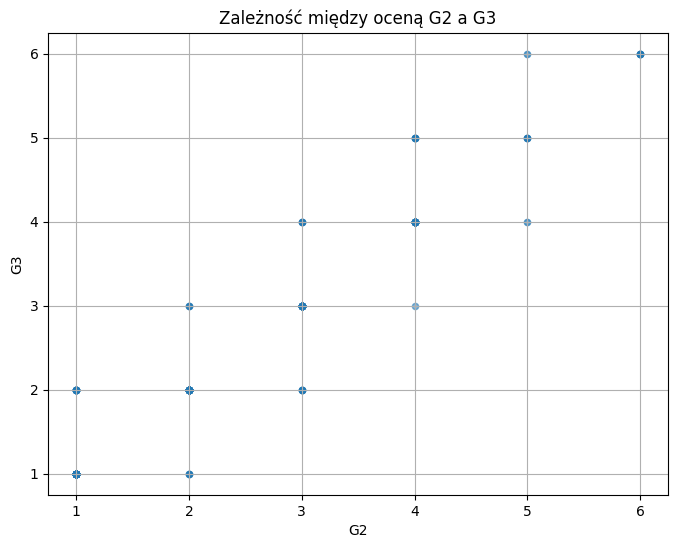

In [76]:
# Wizualizacja zależności między G2 a G3 z uwzględnieniem zagęszczenia punktów
df_train.plot(kind="scatter", x="G2", y="G3", alpha=0.3, figsize=(8, 6))
plt.title("Zależność między oceną G2 a G3")
plt.grid(True)
plt.show()

##Inżynieria cech (Feature Engineering):
W celu zwiększenia mocy predykcyjnej modelu, zaimplementowano trzy nowe zmienne:

G_avg: Średnia arytmetyczna ocen G1 i G2 - pozwala na agregację dotychczasowych postępów ucznia.

absences_per_studytime: Zestawienie nieobecności z czasem nauki pozwala precyzyjniej wyodrębnić uczniów, którzy mają problemy z systematycznością.

studytime_per_grade: Wskaźnik efektywności nauki - mierzy wysiłek wkładany w uzyskanie określonego wyniku.

In [77]:
# Tworzenie zagregowanego wskaźnika wyników nauki
df_train["G_avg"] = (df_train["G1"] + df_train["G2"]) / 2

In [78]:
# Tworzenie wskaźnika zaangażowania (nieobecności względem czasu nauki)
# Dodajemy +1, aby uniknąć dzielenia przez zero
df_train["absences_per_studytime"] = df_train["absences"] / (df_train["studytime"] + 1)

In [79]:
# Tworzenie wskaźnika efektywności nauki
# Mierzy czas nauki w odniesieniu do uzyskanych wyników
df_train["studytime_per_grade"] = df_train["studytime"] / (df_train["G_avg"] + 1)

In [80]:
# Sprawdzenie korelacji wszystkich nowych zmiennych z G3
print(df_train[["G_avg", "absences_per_studytime", "studytime_per_grade", "G3"]].corr()["G3"].sort_values(ascending=False))

G3                        1.000000
G_avg                     0.935847
absences_per_studytime   -0.130423
studytime_per_grade      -0.547012
Name: G3, dtype: float64


In [81]:
# Obliczenie macierzy korelacji dla wszystkich cech numerycznych
corr_matrix = df_train.corr()
print(corr_matrix["G3"].sort_values(ascending=False))

G3                        1.000000
G2                        0.946883
G_avg                     0.935847
G1                        0.871069
Medu                      0.243663
higher                    0.176427
Fedu                      0.169416
studytime                 0.091607
famrel                    0.056493
internet                  0.045831
paid                     -0.002609
activities               -0.010547
freetime                 -0.021374
romantic                 -0.086104
health                   -0.098932
sex                      -0.109157
Dalc                     -0.118339
absences                 -0.126557
absences_per_studytime   -0.130423
age                      -0.135763
goout                    -0.147095
Walc                     -0.149765
failures                 -0.313709
studytime_per_grade      -0.547012
Name: G3, dtype: float64


In [82]:
# Używamy najsilniejszych predyktorów (na podstawie macierzy korelacji)
features = ["G1", "G2", "G_avg", "studytime_per_grade", "failures", "Medu", "higher"]
X = df_train.drop("G3", axis=1)
y = df_train["G3"].copy()

# Czyszczenie danych - pipeline

In [83]:
# Czyszczenie danych - pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Definiujemy, które cechy chcemy użyć
features = ["G1", "G2", "G_avg", "studytime_per_grade", "failures", "Medu", "higher"]

# Definiujemy pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),  # Zabezpieczenie przed brakami
    ('std_scaler', StandardScaler()),               # Standaryzacja wszystkich cech
])

full_pipeline = num_pipeline

# Wybieramy cechy ze zbioru treningowego
X_selected = df_train[features]

# Fit tylko na danych treningowych
X_prepared = num_pipeline.fit_transform(X_selected)

print(f"Liczba uczniów (treningowych): {X_prepared.shape[0]}")
print(f"Liczba cech użytych do nauki: {X_prepared.shape[1]}")

Liczba uczniów (treningowych): 316
Liczba cech użytych do nauki: 7


In [84]:
# Zamiana macierzy z powrotem na czytelną tabelę z nazwami kolumn
X_prepared_df = pd.DataFrame(
    X_prepared,
    columns=features,
    index=df_train.index
)
X_prepared_df.head()

,G1,G2,G_avg,studytime_per_grade,failures,Medu,higher
311,1.142906,0.428908,0.806379,-0.674566,-0.449268,-0.694675,-4.068852
107,1.862345,2.557730,2.277178,-0.626348,-0.449268,0.219981,0.245770
293,2.581784,2.557730,2.644878,-0.316376,-0.449268,0.219981,0.245770
59,1.142906,1.848123,1.541779,-0.902504,-0.449268,1.134636,0.245770
187,1.142906,1.138515,1.174079,-0.799932,-0.449268,-0.694675,0.245770


# Regresja liniowa

W celu przewidywania ocen końcowych (G3) zaimplementowano model regresji liniowej.

Proces obejmował:

Trenowanie modelu: Wykorzystano przygotowane dane (X_prepared), dopasowując model za pomocą metody fit.

Ocena błędu: Obliczono błąd RMSE na całym zbiorze treningowym, który wyniósł ok. 0.45. Oznacza to, że model w swoich prognozach średnio myli się o niecałe pół stopnia w skali ocen.

Walidacja krzyżowa (CV=10): Aby wyeliminować ryzyko przypadkowego dopasowania modelu, zastosowano 10-krotną walidację krzyżową. Średni błąd RMSE z walidacji wyniósł ok. 0.46, przy bardzo niskim odchyleniu standardowym (0.05).

Wniosek: Niskie odchylenie standardowe świadczy o wysokiej stabilności modelu - wyniki są powtarzalne i niezależne od sposobu podziału danych na podzbiory testowe.

In [85]:
# Trening modelu
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_prepared, y)

LinearRegression()

In [86]:
# Obliczanie błędu RMSE
from sklearn.metrics import mean_squared_error
import numpy as np
predictions = lin_reg.predict(X_prepared)
mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)
print(f"Błąd RMSE mojego modelu wynosi: {rmse}")

Błąd RMSE mojego modelu wynosi: 0.4538012559349928


In [87]:
# Funkcja pomocnicza do wyświetlania wyników walidacji
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [88]:
# Walidacja krzyżowa
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(lin_reg, X_prepared, y,
                         scoring="neg_mean_squared_error", cv=10)

rmse_scores = np.sqrt(-scores)
display_scores(rmse_scores)

Scores: [0.39584385 0.41382237 0.58479342 0.46202028 0.48747421 0.483073
 0.43497291 0.39720913 0.46099759 0.47670113]
Mean: 0.4596907878909245
Standard deviation: 0.05287823243922302


# Las losowy

W tym etapie zastosowano algorytm Lasu Losowego, aby sprawdzić, czy model o większej złożoności poradzi sobie z przewidywaniem ocen lepiej niż regresja liniowa.

Walidacja krzyżowa: Wykonano 10-krotną walidację (cv=10), aby uzyskać obiektywną ocenę stabilności modelu na różnych podzbiorach danych.

Punkt odniesienia: Obliczono średnią wartość ocen (2.48), która służy jako punkt odniesienia dla oceny efektywności obu modeli.

In [89]:
# Trening modelu
from sklearn.ensemble import RandomForestRegressor

In [90]:
# Obliczenie błędu RMSE dla danych treningowych
from sklearn.metrics import mean_squared_error

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_prepared, y)

forest_predictions = forest_reg.predict(X_prepared)
forest_mse = mean_squared_error(y, forest_predictions)
forest_rmse = np.sqrt(forest_mse)

print(f"Błąd RMSE Lasu Losowego (na zbiorze treningowym): {forest_rmse:.4f}")

Błąd RMSE Lasu Losowego (na zbiorze treningowym): 0.3286


In [91]:
# Walidacja krzyżowa
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, X_prepared, y,
                                scoring="neg_mean_squared_error", cv=10)

forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [0.45099283 0.44684363 0.643519   0.55248274 0.47516154 0.58704878
 0.42742083 0.49842296 0.5592969  0.58908895]
Mean: 0.523027816678099
Standard deviation: 0.0694220921962225


In [92]:
# Obliczenie średniej oceny jako punkt odniesienia
mean_grade = y.mean()
print(f"Średnia ocena: {mean_grade:.2f}")

Średnia ocena: 2.48


## Grid search


W celu dalszego poprawienia wyników modelu Lasu Losowego, przeprowadzono proces optymalizacji hiperparametrów przy użyciu GridSearchCV.

Cel: Automatyczne znalezienie optymalnej liczby drzew (n_estimators) oraz liczby cech (max_features), które minimalizują błąd modelu.

Metodologia: Przetestowano różne kombinacje parametrów z wykorzystaniem 5-krotnej walidacji krzyżowej (CV=5).

Wynik: Najlepszą konfigurację osiągnięto przy parametrach: max_features=4 oraz n_estimators=100. Model ten wykazuje lepszą stabilność i precyzję predykcji w porównaniu do konfiguracji domyślnej.

In [93]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [30, 50, 100], 'max_features': [2, 4, 6]},
    {'bootstrap': [False], 'n_estimators': [30, 50], 'max_features': [2, 3, 4]},
]
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(X_prepared, y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6],
                          'n_estimators': [30, 50, 100]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [30, 50]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [94]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 100}

In [95]:
grid_search.best_estimator_

RandomForestRegressor(max_features=4, random_state=42)

# Ocena na zbiorze testowym

Po wybraniu najlepszej konfiguracji modelu za pomocą techniki GridSearchCV, przeprowadzono ostateczną weryfikację na wydzielonym zbiorze testowym (strat_test_set).

Cel: Obiektywna ocena zdolności modelu do generalizacji wiedzy na nowych, nieznanych danych.

Proces: Dane testowe zostały przetworzone przez uprzednio wyuczony potok transformacji (full_pipeline), co zapewnia spójność przygotowania danych.

Wynik: Otrzymany błąd RMSE stanowi finalną miarę skuteczności modelu, potwierdzającą, czy model nie uległ przeuczeniu (overfitting).

In [96]:
best_model = grid_search.best_estimator_

In [97]:
# Przygotowanie zbioru testowego
# 1. Tworzymy te same kolumny, które są w zbiorze treningowym
strat_test_set = strat_test_set.copy()  # unika SettingWithCopyWarning
strat_test_set['G_avg'] = (strat_test_set['G1'] + strat_test_set['G2']) / 2
strat_test_set['studytime_per_grade'] = strat_test_set['studytime'] / (strat_test_set['G_avg'] + 1)

X_test = strat_test_set.drop("G3", axis=1)
y_test = strat_test_set["G3"].copy()

features = ["G1", "G2", "G_avg", "studytime_per_grade", "failures", "Medu", "higher"]
X_test_selected = X_test[features]

In [98]:
# Transformacja danych testowych
X_test_prepared = full_pipeline.transform(X_test_selected)

# Użycie najlepszego modelu znalezionego przez GridSearch
final_model = grid_search.best_estimator_

# Wykonanie predykcji
final_predictions = final_model.predict(X_test_prepared)

# Obliczenie ostatecznego błędu RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print(f"Ostateczny błąd RMSE na zbiorze testowym: {final_rmse:.4f}")

Ostateczny błąd RMSE na zbiorze testowym: 0.5302


In [99]:
# RMSE Regresji Liniowej na zbiorze testowym
lin_predictions_test = lin_reg.predict(X_test_prepared)
lin_final_mse = mean_squared_error(y_test, lin_predictions_test)
lin_final_rmse = np.sqrt(lin_final_mse)
print(f"RMSE Regresji Liniowej na zbiorze testowym: {lin_final_rmse:.4f}")

RMSE Regresji Liniowej na zbiorze testowym: 0.4579


# Podsumowanie i porównanie modeli

W ramach projektu przetestowano dwa modele uczenia maszynowego w celu przewidywania końcowych ocen uczniów (G3): Regresję Liniową oraz Zoptymalizowany Las Losowy (Random Forest).

Porównanie wyników (błąd RMSE):

Regresja Liniowa: błąd RMSE na zbiorze testowym wyniósł 0.4579

Las Losowy: błąd RMSE na zbiorze testowym wyniósł 0.5302

Wnioski i wskazanie lepszego modelu:
Zdecydowanie lepszym modelem okazała się Regresja Liniowa (RMSE = 0.4579) w porównaniu do Lasu Losowego (RMSE = 0.5302).

Może to wynikać z małego rozmiaru zbioru danych (395 uczniów) oraz dyskretnego charakteru zmiennej docelowej (tylko 6 wartości w skali 1-6), co utrudnia modelowi drzewiastemu generalizację na nowych danych. Regresja liniowa, jako model prostszy, lepiej radzi sobie w sytuacji gdy danych jest niewiele.